# Week 6: t-Test: 빈도주의 vs 베이지안

## 학습 목표
빈도주의 t-Test와 베이지안 관점 비교.

## 이론적 배경 (Mathematical Background)

t-statistic:  
$$ t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}} $$

## 데이터 시뮬레이션 및 검증 목적 (Data Simulation & Verification Purpose)

### 시뮬레이션 목적 (Purpose of Simulation)
이 시뮬레이션의 목적은 **독립 표본 t-검정(Independent Samples t-test)**을 사용하여 두 집단(Group A와 Group B)의 평균 간에 통계적으로 유의미한 차이가 있는지 확인하는 것입니다. <br>
우리는 의도적으로 차이가 있는 두 집단을 생성합니다 (A: 평균 100, B: 평균 110). t-검정이 이 차이를 감지해내는지(p-value < 0.05)를 검증합니다.

The purpose of this simulation is to use an **Independent Samples t-test** to determine if there is a statistically significant difference between the means of two groups (Group A and Group B). <br>
We intentionally generate two groups with different means (A: mean 100, B: mean 110). We verify if the t-test can detect this difference (i.e., p-value < 0.05).

### 함수 설명 (Function Explanation): `stats.ttest_ind`
*   **기능(Function)**: 두 개의 독립적인 표본 집단의 평균 등가성을 검정합니다. (Calculates the T-test for the means of two independent samples of scores.)
*   **검증 내용**: 두 집단의 평균이 통계적으로 다른지 확인합니다.
*   **귀무가설(Null Hypothesis)**: 두 집단의 평균이 같다. ($\mu_A = \mu_B$)
*   **해석(Interpretation)**: p-value가 유의수준(예: 0.05)보다 작으면 귀무가설을 기각하고 두 집단의 평균이 다르다고 결론 내립니다.

In [28]:
import numpy as np
from scipy import stats

# 재현성을 위해 시드 설정 (Set seed for reproducibility)
# 난수 생성기의 초기값을 고정하여 항상 같은 데이터가 생성되도록 합니다.
np.random.seed(42)

# 두 그룹의 데이터 생성 (Generating data for two groups)
# Group A: Mean=100, SD=15, N=30
# Group B: Mean=110, SD=15, N=30
group_A = np.random.normal(100, 15, 30)
group_B = np.random.normal(110, 15, 30)

# 독립 표본 t-검정 수행 (Perform Independent Samples t-test)
# stats.ttest_ind: 두 독립 표본의 평균 차이를 비교하는 함수 (Comparies means of two independent samples)
t_stat, p_val = stats.ttest_ind(group_A, group_B)

print(f'T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}')

# 간단한 해석 출력 (Simple output of interpretation)
if p_val < 0.05:
    print("Result: Significant difference found (유의미한 차이 발견 - 귀무가설 기각)")
else:
    print("Result: No significant difference (유의미한 차이 없음 - 귀무가설 기각 실패)")

T-statistic: -3.10, P-value: 0.0030
Result: Significant difference found (유의미한 차이 발견 - 귀무가설 기각)


## 결과 시뮬레이션 및 가시화 (Visualization)
생성된 데이터 또는 분석 결과를 시각화합니다.

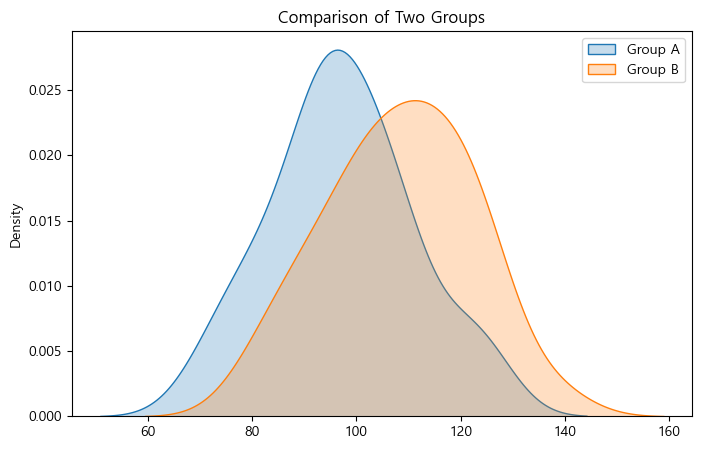

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(group_A, fill=True, label='Group A')
sns.kdeplot(group_B, fill=True, label='Group B')
plt.title('Comparison of Two Groups')
plt.legend()
plt.show()

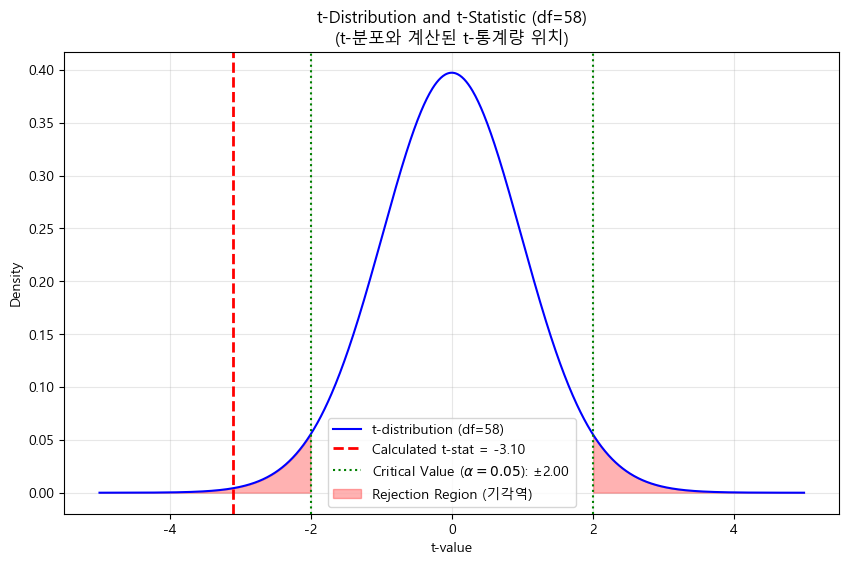

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import platform

# 한글 폰트 설정 (Korean Font Configuration)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux
    plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지 (Prevent minus sign corruption)
plt.rcParams['axes.unicode_minus'] = False

# 자유도 계산 (Degrees of freedom)
# 독립 표본 t-검정 (등분산 가정): df = n1 + n2 - 2
df = len(group_A) + len(group_B) - 2

# t-분포 시각화를 위한 x축 범위 설정 (Set x-axis range for t-distribution visualization)
x_range = np.linspace(-5, 5, 1000)
# 만약 계산된 t-통계량이 범위 밖이라면 범위를 확장 (Extend range if calculated t-stat is out of bounds)
if abs(t_stat) > 4.5:
    x_range = np.linspace(-(abs(t_stat)+1), abs(t_stat)+1, 1000)

# t-분포의 확률밀도함수 (PDF of t-distribution)
y_pdf = stats.t.pdf(x_range, df)

plt.figure(figsize=(10, 6))

# t-분포 그리기 (Plot t-distribution)
plt.plot(x_range, y_pdf, label=f't-distribution (df={df})', color='blue')

# 계산된 t-통계량 표시 (Mark calculated t-statistic)
plt.axvline(t_stat, color='red', linestyle='--', linewidth=2, label=f'Calculated t-stat = {t_stat:.2f}')

# 임계값 (Critical values) - 유의수준 0.05, 양측검정 (alpha=0.05, two-tailed)
alpha = 0.05
critical_val = stats.t.ppf(1 - alpha/2, df)

# 기각역 표시 (Mark Rejection Regions)
plt.axvline(critical_val, color='green', linestyle=':', label=f'Critical Value ($\\alpha=0.05$): ±{critical_val:.2f}')
plt.axvline(-critical_val, color='green', linestyle=':')

# 기각역 색칠 (Shade rejection regions)
plt.fill_between(x_range, y_pdf, where=(x_range >= critical_val), color='red', alpha=0.3, label='Rejection Region (기각역)')
plt.fill_between(x_range, y_pdf, where=(x_range <= -critical_val), color='red', alpha=0.3)

plt.title(f't-Distribution and t-Statistic (df={df})\n(t-분포와 계산된 t-통계량 위치)')
plt.xlabel('t-value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Q: 그래프에서 Prob[-2 < t < 2] = 0.95 인가요? (Is Prob[-2 < t < 2] = 0.95 in the plot?)

**답변 (Answer):**
네, **이 특정 시뮬레이션(df=58)에서는 거의 정확히 그렇습니다.** 하지만 모든 t-분포에서 그런 것은 아닙니다.
Yes, **for this specific simulation (df=58), it is almost exactly true.** However, this is not true for all t-distributions.

**상세 설명 (Detailed Explanation):**

1.  **현재 시뮬레이션 (Current Simulation, $N=60, df=58$)**:
    *   자유도가 58일 때, 95% 신뢰구간의 임계값(Critical Value)은 약 **2.0017**입니다.
    *   따라서 $\pm 2$ 사이의 면적은 거의 정확하게 95%가 됩니다.
    *   *For df=58, the critical value for 95% confidence is approximately **2.0017**. Thus, the area between $\pm 2$ is almost exactly 95%.*

2.  **일반적인 규칙 (General Rule)**:
    *   **정규분포 (Standard Normal, Z)**: 임계값은 **1.96**입니다. 표본이 무한히 많을 때($N \to \infty$) t-분포는 정규분포에 수렴합니다.
    *   **작은 표본 (Small Samples)**: 표본이 작을수록 꼬리가 두꺼워져서 임계값이 2보다 훨씬 커집니다 (예: df=5일 때 임계값은 2.57).
    *   *For a Normal Distribution (Z), the value is exactly **1.96**. For t-distributions, as the sample size decreases, the tails get fatter and the value grows (e.g., for df=5, it is 2.57).*

**요약 (Summary)**:
자유도가 60 근처일 때 t-분포의 95% 임계값은 우연히도 정수 **2**에 매우 가깝습니다. 이것이 그래프에서 기각역이 정확히 $\pm 2$ 근처에서 시작되는 이유입니다.
*When the degrees of freedom are around 60, the 95% critical value of the t-distribution coincidentally falls very close to the integer **2**. This is why the rejection regions in the plot appear to start exactly at $\pm 2$.*

## 베이지안 t-Test (Bayesian t-Test with Stan)

빈도주의 t-test와 달리, 베이지안 접근법은 모수(평균의 차이)에 대한 **전체 확률 분포(Posterior Distribution)**를 추정합니다. <br>
이를 통해 "평균 차이가 0보다 클 확률"이나 "평균 차이가 특정 범위(ROPE) 안에 있을 확률"을 직접 계산할 수 있습니다.

Unlike the frequentist t-test, the Bayesian approach estimates the **full posterior distribution** of the parameters (difference of means). <br>
This allows us to directly calculate probabilities such as "the probability that the difference in means is greater than 0" or "the probability that the difference falls within a specific range (ROPE)".

우리는 `CmdStanPy`와 `Stan` 언어를 사용하여 평균의 차이($\mu_B - \mu_A$)를 추정합니다.
We use `CmdStanPy` and the `Stan` language to estimate the difference in means ($\mu_B - \mu_A$).

In [31]:
stan_code = """
data {
  int<lower=0> N1;
  int<lower=0> N2;
  vector[N1] y1;
  vector[N2] y2;
}
parameters {
  real mu1;
  real mu2;
  real<lower=0> sigma1;
  real<lower=0> sigma2;
}
model {
  // Priors (Weakly informative)
  // Scores are roughly around 100
  mu1 ~ normal(100, 50);
  mu2 ~ normal(100, 50);
  sigma1 ~ cauchy(0, 20);
  sigma2 ~ cauchy(0, 20);
  
  // Likelihood
  y1 ~ normal(mu1, sigma1);
  y2 ~ normal(mu2, sigma2);
}
generated quantities {
  real diff_means;
  real cohens_d;
  diff_means = mu2 - mu1;
  // Simplified Cohen's d assuming similar variances, or just average variance  
  cohens_d = (mu2 - mu1) / sqrt((sigma1^2 + sigma2^2) / 2);
}
"""

# // Cohen's d 공식 설명 (Note on Cohen's d Formula):
# // Cohen's d는 "통합 표준편차(Pooled Standard Deviation)"를 분모로 사용합니다.
# // Cohen's d uses "Pooled Standard Deviation" as the denominator.
# // sigma_pooled = sqrt((sigma1^2 + sigma2^2) / 2)
# // 이는 두 집단의 분산을 평균낸 후 제곱근을 취한 것입니다 (평균 표준오차와 다름).
# // This is the square root of the average variance (distinct from Standard Error).


with open('bayes_ttest.stan', 'w') as f:
    f.write(stan_code)

print("Stan model file ('bayes_ttest.stan') created successfully.")

Stan model file ('bayes_ttest.stan') created successfully.


<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
C:\Users\yongd\AppData\Local\Temp\ipykernel_5736\2544056610.py:38: SyntaxWarning: invalid escape sequence '\m'
  sns.kdeplot(mu1, fill=True, label='Group A Mean ($\mu_A$)', color='blue', alpha=0.3)
C:\Users\yongd\AppData\Local\Temp\ipykernel_5736\2544056610.py:39: SyntaxWarning: invalid escape sequence '\m'
  sns.kdeplot(mu2, fill=True, label='Group B Mean ($\mu_B$)', color='orange', alpha=0.3)
C:\Users\yongd\AppData\Local\Temp\ipykernel_5736\2544056610.py:49: SyntaxWarning: invalid escape sequence '\m'
  sns.histplot(diff_means, kde=True, color='skyblue', label='Posterior Difference ($\mu_B - \mu_A$)')
12:47:21 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS5101\

Compiling Stan model...


12:47:30 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bayes_ttest.exe


Sampling...


12:47:30 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:47:30 - cmdstanpy - INFO - CmdStan done processing.


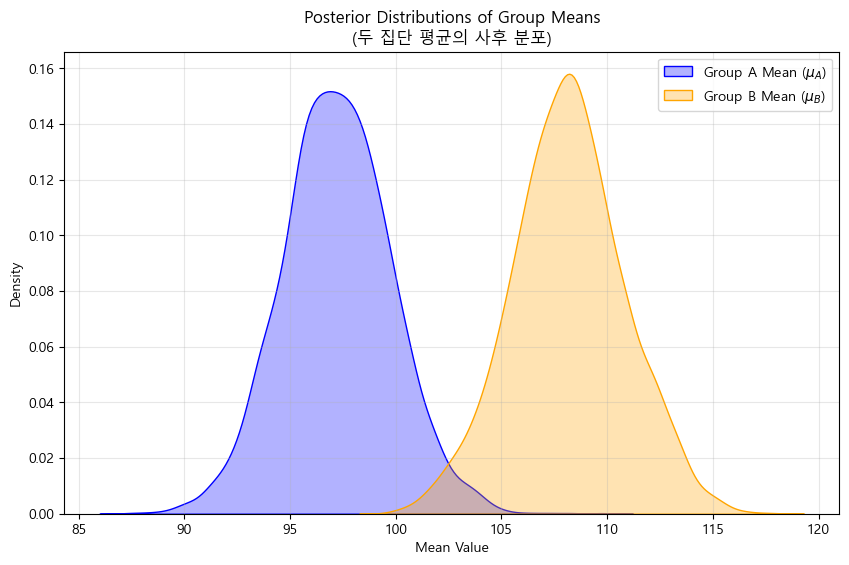

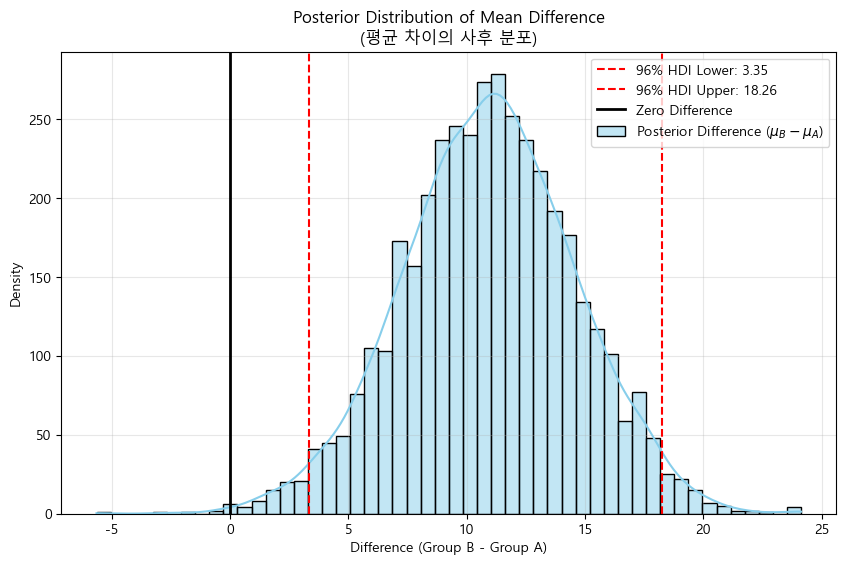

Mean A (Estimated): 97.21
Mean B (Estimated): 108.16
Mean Difference (Estimated): 10.94
96% HDI of Diff: [3.35, 18.26]
Probability that Group B > Group A: 0.9980
Result: 0 is NOT in 96% HDI -> Credible/Reliable Difference (신뢰할 만한 차이)


In [32]:
import os
from cmdstanpy import CmdStanModel
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Stan 코드 파일 생성 확인 (Ensure Stan file exists/is targeted)
# Stan model is defined in 'bayes_ttest.stan' created in the directory
stan_file = 'bayes_ttest.stan'

# 데이터 준비 (Data Preparation)
stan_data = {
    'N1': len(group_A),
    'N2': len(group_B),
    'y1': group_A,
    'y2': group_B
}

print("Compiling Stan model...")
# 모델 컴파일 (Compile Model)
# force_compile=False: 변경사항이 없으면 재컴파일하지 않음 (Do not recompile if no changes)
model = CmdStanModel(stan_file=stan_file)

print("Sampling...")
# 샘플링 수행 (Sampling)
fit = model.sample(data=stan_data, output_dir='.', show_progress=True)

# 사후확률조사 (Posterior Analysis)
draws = fit.draws_pd()
mu1 = draws['mu1']
mu2 = draws['mu2']
diff_means = draws['diff_means']
cohens_d = draws['cohens_d']

# --- Plot 1: 두 집단 평균의 사후 분포 (Posterior Distributions of Means) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(mu1, fill=True, label='Group A Mean ($\mu_A$)', color='blue', alpha=0.3)
sns.kdeplot(mu2, fill=True, label='Group B Mean ($\mu_B$)', color='orange', alpha=0.3)
plt.title('Posterior Distributions of Group Means\n(두 집단 평균의 사후 분포)')
plt.xlabel('Mean Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot 2: 평균 차이의 사후 분포 (Posterior Distribution of Difference) ---
plt.figure(figsize=(10, 6))
sns.histplot(diff_means, kde=True, color='skyblue', label='Posterior Difference ($\mu_B - \mu_A$)')

# 96% HDI (Highest Density Interval) 계산
hdi_prob = 0.96
hdi_min = np.percentile(diff_means, (1 - hdi_prob) / 2 * 100)
hdi_max = np.percentile(diff_means, (1 - (1 - hdi_prob) / 2) * 100)

plt.axvline(hdi_min, color='red', linestyle='--', label=f'{int(hdi_prob*100)}% HDI Lower: {hdi_min:.2f}')
plt.axvline(hdi_max, color='red', linestyle='--', label=f'{int(hdi_prob*100)}% HDI Upper: {hdi_max:.2f}')
plt.axvline(0, color='black', linestyle='-', linewidth=2, label='Zero Difference')

plt.title('Posterior Distribution of Mean Difference\n(평균 차이의 사후 분포)')
plt.xlabel('Difference (Group B - Group A)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 결과 요약 출력 (Print Summary)
print(f"Mean A (Estimated): {mu1.mean():.2f}")
print(f"Mean B (Estimated): {mu2.mean():.2f}")
print(f"Mean Difference (Estimated): {diff_means.mean():.2f}")
print(f"{int(hdi_prob*100)}% HDI of Diff: [{hdi_min:.2f}, {hdi_max:.2f}]")
print(f"Probability that Group B > Group A: {(diff_means > 0).mean():.4f}")

if (hdi_min > 0) or (hdi_max < 0):
    print(f"Result: 0 is NOT in {int(hdi_prob*100)}% HDI -> Credible/Reliable Difference (신뢰할 만한 차이)")
else:
    print(f"Result: 0 is in {int(hdi_prob*100)}% HDI -> No Credible Difference (신뢰할 만한 차이 없음)")

## 효과 크기 (Effect Size: Cohen's d)

### 목적 (Purpose)
p-value나 신뢰구간은 "차이가 있다/없다" 혹은 "차이의 크기가 얼마인가(비표준화)"를 알려주지만, **"그 차이가 얼마나 큰가?(실질적인 중요성)"**를 비교하기에는 부족할 수 있습니다. <br>
특히 측정 단위가 다른 연구들을 비교할 때 **표준화된 지표**가 필요합니다. **Cohen's d**는 가장 널리 쓰이는 효과 크기 지표로, 두 집단의 평균 차이를 통합 표준편차로 나눈 값입니다.

P-values or confidence intervals tell us "if there is a difference" or "the magnitude of the difference (unstandardized)", but they may not sufficient to judge **"how large is the difference? (practical significance)"**. <br>
Especially when comparing studies with different measurement units, a **standardized index** is needed. **Cohen's d** is the most widely used effect size metric, calculated as the difference between two means divided by the pooled standard deviation.

$$ d = \frac{\mu_B - \mu_A}{\sigma_{pooled}} $$

### 해석 기준 (Interpretation Guidelines)
일반적으로 Cohen(1988)이 제시한 기준을 따릅니다:
*   **0.2**: 작은 효과 (Small effect) - 눈으로 식별하기 어려움.
*   **0.5**: 중간 효과 (Medium effect) - 눈으로 식별 가능함.
*   **0.8**: 큰 효과 (Large effect) - 확연한 차이.

베이지안 분석에서는 Cohen's d 역시 하나의 모수로 취급하여 **Cohen's d의 사후 분포(Posterior Distribution)**를 구할 수 있습니다. 이를 통해 효과 크기의 불확실성까지 파악할 수 있습니다.
In Bayesian analysis, Cohen's d is also treated as a parameter, so we can obtain the **Posterior Distribution of Cohen's d**. This allows us to understand the uncertainty of the effect size.

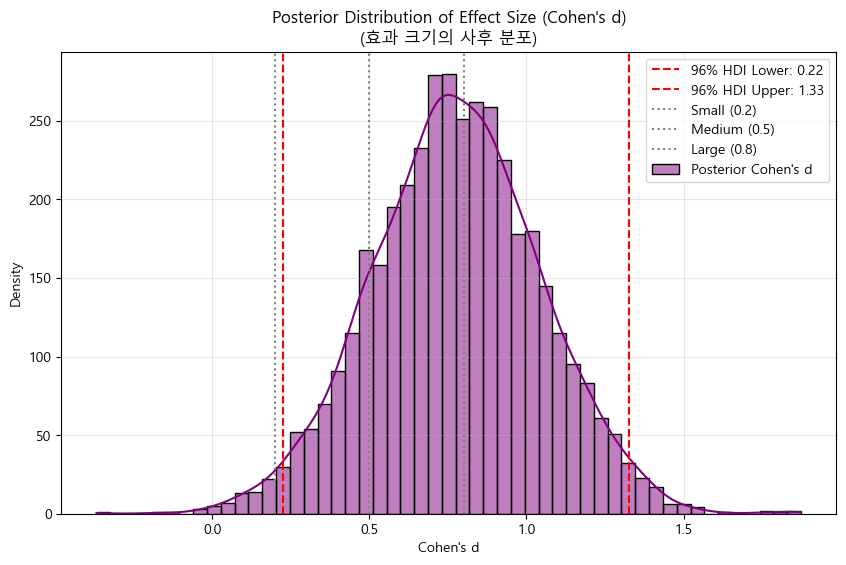

Mean Cohen's d: 0.78
96% HDI for Cohen's d: [0.22, 1.33]
--------------------------------------------------
Effect Size Probabilities (효과 크기 확률):
The effect size is Large (d > 0.8) with probability: 0.4655 (46.55%)
Medium or larger (d > 0.5) with probability: 0.8502 (85.02%)
Small or larger (d > 0.2) with probability: 0.9832 (98.32%)
Negligible/Not effective (d <= 0.2) with probability: 0.0168 (1.68%)
--------------------------------------------------


In [33]:
# Cohen's d의 사후 분포 시각화 (Visualization of Posterior Cohen's d)

plt.figure(figsize=(10, 6))
sns.histplot(cohens_d, kde=True, color='purple', label="Posterior Cohen's d")

# 96% HDI for Cohen's d
hdi_min_d = np.percentile(cohens_d, (1 - hdi_prob) / 2 * 100)
hdi_max_d = np.percentile(cohens_d, (1 - (1 - hdi_prob) / 2) * 100)

plt.axvline(hdi_min_d, color='red', linestyle='--', label=f'{int(hdi_prob*100)}% HDI Lower: {hdi_min_d:.2f}')
plt.axvline(hdi_max_d, color='red', linestyle='--', label=f'{int(hdi_prob*100)}% HDI Upper: {hdi_max_d:.2f}')

# 기준선 표시 (Reference lines for Small, Medium, Large effects)
plt.axvline(0.2, color='gray', linestyle=':', label='Small (0.2)')
plt.axvline(0.5, color='gray', linestyle=':', label='Medium (0.5)')
plt.axvline(0.8, color='gray', linestyle=':', label='Large (0.8)')

plt.title("Posterior Distribution of Effect Size (Cohen's d)\n(효과 크기의 사후 분포)")
plt.xlabel("Cohen's d")
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 요약 (Summary)
print(f"Mean Cohen's d: {cohens_d.mean():.2f}")
print(f"{int(hdi_prob*100)}% HDI for Cohen's d: [{hdi_min_d:.2f}, {hdi_max_d:.2f}]")

# 확률 계산 (Probability Calculation)
prob_large = (cohens_d > 0.8).mean()
prob_medium = (cohens_d > 0.5).mean()
prob_small = (cohens_d > 0.2).mean()
prob_negligible = (cohens_d <= 0.2).mean()

print("-" * 50)
print("Effect Size Probabilities (효과 크기 확률):")
print(f"The effect size is Large (d > 0.8) with probability: {prob_large:.4f} ({prob_large*100:.2f}%)")
print(f"Medium or larger (d > 0.5) with probability: {prob_medium:.4f} ({prob_medium*100:.2f}%)")
print(f"Small or larger (d > 0.2) with probability: {prob_small:.4f} ({prob_small*100:.2f}%)")
print(f"Negligible/Not effective (d <= 0.2) with probability: {prob_negligible:.4f} ({prob_negligible*100:.2f}%)")
print("-" * 50)

### 베이지안 보고 방식에 대한 참고 (Note on Bayesian Reporting Style)

**Q: 다음과 같이 보고하는 것이 논리적으로 타당하며 다른 연구자들도 사용하는 방식인가요?**
> "The effect size is large with probability X, medium or large with probability Y..."

**A: 네, 논리적으로 타당하며 베이지안 통계 분석에서 권장되는 보고 방식 중 하나입니다.**
**Yes, it is logically sound and consistent with recommended practices in Bayesian reporting.**

1.  **논리적 타당성 (Logical Correctness)**:
    *   베이지안 추론의 핵심 장점은 모수(여기서는 Cohen's d)에 대한 **확률적 진술(Probabilistic Statement)**이 가능하다는 것입니다.
    *   빈도주의(p-value)에서는 "효과가 크다/작다"라고 단정하거나 기각 여부만 말할 수 있지만, 베이지안에서는 "효과가 0.8보다 클 확률이 85%다"라고 말하는 것이 수학적으로 정확한 표현입니다.

2.  **관습적 사용 (Common Usage)**:
    *   Kruschke (2014) 등 베이지안 통계학자들은 **"ROPE(Region of Practical Equivalence)"**와 함께 사후 분포의 질량(mass)이 특정 구간에 얼마나 포함되는지를 보고할 것을 강력히 권장합니다.
    *   예를 들어, "The probability that the effect size exceeds 0.5 (medium effect) is 92%"와 같은 진술은 베이지안 논문에서 흔히 볼 수 있는 매우 명확하고 유용한 보고 방식입니다.

따라서 제안하신 문장 구조는 베이지안 분석의 강점을 잘 살린 매우 훌륭한 표현입니다.
Therefore, the sentence structure you proposed effectively utilizes the strengths of Bayesian analysis and is an excellent way to report results.

## t-Test Cheat Sheet

The table below summarizes common t-test variants by **purpose** and **main concept** (what is being compared/tested).

| Analysis | Purpose | Main concept / statistic | Example question |
|---|---|---|---|
| **One-sample t-test** | Compare a sample mean to a reference value $\mu_0$ | $t=(\bar{x}-\mu_0)/(s/\sqrt{n})$ uses the standard error of the mean | “Is the mean different from 50?” |
| **Paired t-test** | Compare two measurements from the same units (pre/post, matched pairs) | Do a **one-sample t-test on differences** $d_i=x_{i,post}-x_{i,pre}$ | “Is the mean change 0?” |
| **Independent t-test (pooled / equal variances)** | Compare means of two independent groups assuming equal variances | Uses pooled variance $s_p^2$; $t=(\bar{x}_1-\bar{x}_2)/(s_p\sqrt{1/n_1+1/n_2})$ | “Do group A and B have different means?” |
| **Welch t-test (unequal variances)** | Compare means of two independent groups without assuming equal variances | Uses separate variances + Welch–Satterthwaite df correction | “Means differ when variances are unequal?” |
| **One-sided vs two-sided** | Directional vs non-directional inference | Changes the alternative: “$\mu_2>\mu_1$” vs “$\mu_2\neq\mu_1$” (affects tails/decision rule) | “Is B greater than A?” vs “Is B different from A?” |
| **Nonparametric alternatives** | When normality/outliers are a concern for mean-based tests | Independent: Mann–Whitney U; Paired: Wilcoxon signed-rank (rank-based) | “Compare groups without relying on normality?” |
| **Bayesian t-test (Bayesian alternative framing)** | Direct probability statements about mean difference and effect size | Posterior for $\mu_2-\mu_1$, HDI, ROPE, $P(\mu_2-\mu_1>0\mid data)$ | “What is the probability the difference is > 0?” |

---

### Can all of these be analyzed with Stan/CmdStanPy?

- **Yes, for the mean-based t-test family (one-sample / paired / independent / Welch)**: you can write a generative model in Stan and sample with CmdStanPy. In practice this looks like normal likelihood + priors on means and SD(s).
  - One-sample: $x_i\sim\mathcal{N}(\mu,\sigma)$ and infer $\mu-\mu_0$.
  - Paired: model differences $d_i\sim\mathcal{N}(\delta,\sigma_d)$ and infer $\delta$.
  - Independent pooled: share a common $\sigma$; Welch-style: use separate $\sigma_1,\sigma_2$.
- **One-sided vs two-sided** is not a “different model” in Bayes: you typically fit the same model and report probabilities like $P(\mu_2-\mu_1>0\mid data)$ (directional) or $P(|\mu_2-\mu_1|>\text{ROPE}\mid data)$ (practical difference).
- **Rank-based nonparametric tests (Mann–Whitney, Wilcoxon)** are not usually replicated *as-is* in Stan because they are defined via ranks and exact null distributions. However, you can often use a **Bayesian robust alternative** instead (e.g., Student-t likelihood, mixture models, or models for medians/quantiles) and then do posterior comparisons.

**Note:** t-tests can also be viewed as special cases of linear models (and Bayesian regression), e.g., independent t-test corresponds to $y\sim\beta_0+\beta_1 I(\text{Group}=B)+\epsilon$ with testing/summarizing $\beta_1$.